# [Bacterial Colony Growth](@id Bacteries)

In this example, we are going to create a bacterial model and grow a colony using it.

 - The implementation of the force interaction dynamics is the one presented by [Volfson et al. (2008)](https://www.pnas.org/doi/abs/10.1073/pnas.0706805105)
 - We use GPU accelerated dynamics

As described in other models, it is advised that the models are constructed by parts to avoid having to find bugs in a very complex system. Hence, we will split the model in two parts:

 - Forces model
 - Growth model

## Load the packages

In [26]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 4 threads 😎


In [27]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [28]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [29]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [30]:
import Pkg

# Activa el entorno del proyecto
# Pkg.activate("C:/Users/julia/OneDrive/Escritorio/phd/Bacteria_ABM/ABM_CBM/")

Pkg.activate("/home/julia/Escritorio/Projects/Pushing/ABM_CBM")
# Pkg.activate("C:/Users/julia/OneDrive/Escritorio/phd/Bacteria_ABM/ABM_CBM/")


# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `~/Escritorio/Projects/Pushing/ABM_CBM`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Project.toml`
  No Changes to `~/Escritorio/Projects/Pushing/ABM_CBM/Manifest.toml`
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA /home/julia/.julia/packages/CUDA/jdJ7Z/lib/cudadrv/version.jl:82


In [31]:
# import Pkg
# Pkg.activate("/home/julia/Escritorio/Projects/Pushing/ABM_CBM")
# Pkg.update()              # Alinea versiones del stack SciML (ver punto 2)
# Pkg.precompile()

# # using Revise
# # using CellBasedModels
# # using CUDA                # <- comentar por ahora
# # CUDA.set_runtime_version!(v"12.2")  # <- comentar
# # ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # <- comentar

# using Revise
# using CellBasedModels
# using Distributions
# using CairoMakie
# using JSON
# CairoMakie.activate!()


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [32]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
            :eta=>Float64,

        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [33]:
com = Community(rod2D,
            N=30,
            dt=0.0001,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=1* 1.E6 *m/(t^2*d) #Pa
com.eta = 200 *m/(t^2*d) #Pa h
 

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [34]:
com.N

30

In [35]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*10-5
    com.y[i] = rand()*10-5
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [36]:
com.theta[1]=20

20

In [37]:
evolve!(com,steps=10000,saveEach=100,preallocateAgents=com.N)

In [38]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

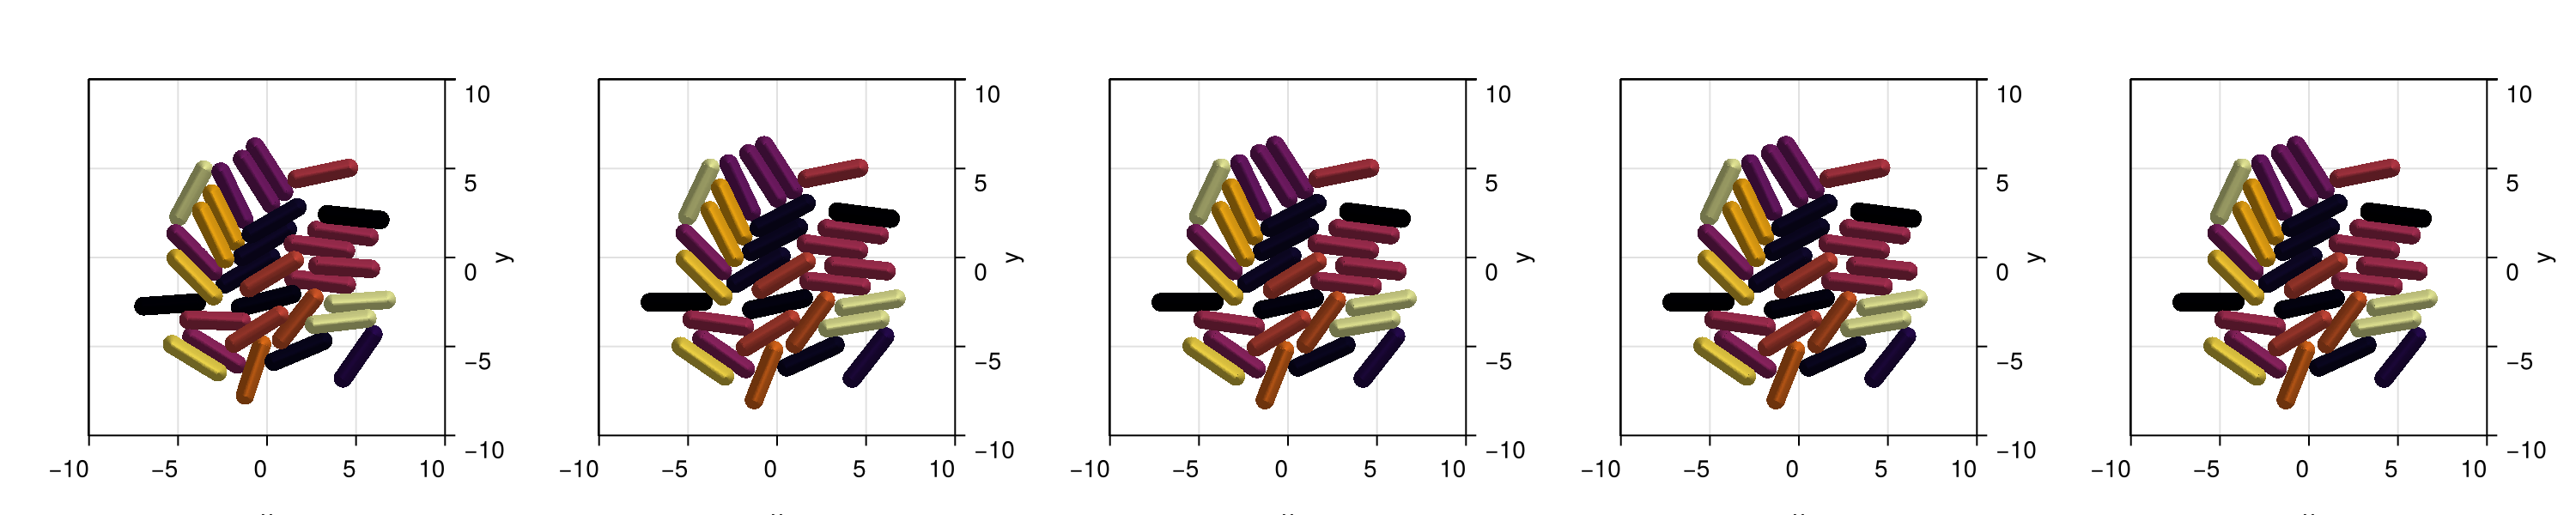

CairoMakie.Screen{IMAGE}


In [39]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:theta],
    colorrange = (0, 2*pi)
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [40]:

function log_community_state(parameters::OrderedDict, t::Int, path::String )
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String )
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 1 method)

In [41]:
function plotAgents3D!(ax, x, y, z, d, l, theta, phi, p; colormap=:inferno, kargs...)
    # Recomendado: en tu Axis3 usa aspect=:data para evitar distorsión de ejes
    # ej.: ax = Axis3(fig[1,1]; aspect=:data)

    for (xi, yi, zi, di, li, thetai, phii, pi) in zip(x, y, z, d, l, theta, phi, p)
        # Dirección unitaria u(θ,φ)
        ux = cos(thetai) * cos(phii)
        uy = sin(thetai) * cos(phii)
        uz = sin(phii)

        # Polos (extremos)
        x_plus  = xi + 0.5 * li * ux
        y_plus  = yi + 0.5 * li * uy
        z_plus  = zi + 0.5 * li * uz

        x_minus = xi - 0.5 * li * ux
        y_minus = yi - 0.5 * li * uy
        z_minus = zi - 0.5 * li * uz

        r = Float32(di/2)

        # Color: usa tu escalar 'pi' con colormap (fija un rango 0..1; ajusta si necesitas)
        colorrange = (0.0, 1.0)
        # Cilindro que UNE los polos (Makie lo orienta solo con p1->p2)


        # Esferas en los polos
        mesh!(ax, Sphere(Point3f(x_plus,  y_plus,  z_plus),  r);
             color=pi, colormap=colormap, colorrange=colorrange, kargs...)
        mesh!(ax, Sphere(Point3f(x_minus, y_minus, z_minus), r);
             color=pi, colormap=colormap, colorrange=colorrange, kargs...)
        mesh!(ax, Cylinder(
            Point3f(x_minus, y_minus, z_minus),
            Point3f(x_plus,  y_plus,  z_plus),
            r);
            color=pi, colormap=colormap, colorrange=colorrange, kargs...)


    end
    return
end


plotAgents3D! (generic function with 1 method)

In [42]:
# using GeometryBasics, Makie

view_dir(az, el) = Vec3f(cos(az)*cos(el), sin(az)*cos(el), sin(el))

function painter_perm(ax::Axis3, x, y, z)
    az = ax.azimuth[]; el = ax.elevation[]
    v  = view_dir(az, el)
    depths = x .* v[1] .+ y .* v[2] .+ z .* v[3]
    sortperm(depths; rev=false)  # far → near (lejos → cerca)
end

function plotAgents3D_auto!(ax, x, y, z, d, l, theta, phi, p; colormap=:inferno, colorrange=(0,1), kwargs...)
    perm = painter_perm(ax, x, y, z)
    for i in perm
        xi, yi, zi = x[i], y[i], z[i]
        di, li = d[i], l[i]
        thetai, phii, pi = theta[i], phi[i], p[i]

        ux = cos(thetai) * cos(phii)
        uy = sin(thetai) * cos(phii)
        uz = sin(phii)

        x_plus  = xi + 0.5li*ux; y_plus  = yi + 0.5li*uy; z_plus  = zi + 0.5li*uz
        x_minus = xi - 0.5li*ux; y_minus = yi - 0.5li*uy; z_minus = zi - 0.5li*uz
        r = Float32(di/2)

        mesh!(ax, Sphere(Point3f(x_plus,  y_plus,  z_plus),  r);
             color=pi, colormap=colormap, colorrange=colorrange, kwargs...)
        mesh!(ax, Sphere(Point3f(x_minus, y_minus, z_minus), r);
             color=pi, colormap=colormap, colorrange=colorrange, kwargs...)
        mesh!(ax, Cylinder(Point3f(x_minus, y_minus, z_minus), Point3f(x_plus, y_plus, z_plus), r);
             color=pi, colormap=colormap, colorrange=colorrange, kwargs...)

    end
    return
end


function plotAgents3Drod!(ax, x, y, z, d, l, theta, phi, p; colormap=:inferno, colorrange=(0,1), kwargs...)
    perm = painter_perm(ax, x, y, z)
    for i in perm
        xi, yi, zi = x[i], y[i], z[i]
        di, li = d[i], l[i]
        thetai, phii, pi = theta[i], phi[i], p[i]

        ux = cos(thetai) * cos(phii)
        uy = sin(thetai) * cos(phii)
        uz = sin(phii)

        x_plus  = xi + 0.5li*ux; y_plus  = yi + 0.5li*uy; z_plus  = zi + 0.5li*uz
        x_minus = xi - 0.5li*ux; y_minus = yi - 0.5li*uy; z_minus = zi - 0.5li*uz
        r = Float32(di/2)


        mesh!(ax, Cylinder(Point3f(x_minus, y_minus, z_minus), Point3f(x_plus, y_plus, z_plus), r);
             color=pi, colormap=colormap, colorrange=colorrange, kwargs...)

    end
    return
end


plotAgents3Drod! (generic function with 1 method)

# Terracing


In [43]:
@inline function rod_poles3d_ordered(x,y,z,l,theta,phi)
    ux,uy,uz = rod_dir3d(theta, phi)
    hx,hy,hz = 0.5l*ux, 0.5l*uy, 0.5l*uz
    return (x+hx, y+hy, z+hz), (x-hx, y-hy, z-hz)  # (+, −)
end

rod_poles3d_ordered (generic function with 1 method)

In [44]:
@inline function rod_dir3d(theta, phi)
    cx = cos(theta); sx = sin(theta)
    cp = cos(phi);   sp = sin(phi)
    return (cx*cp, sx*cp, sp)               # u = (cosθ cosφ, sinθ cosφ, sinφ)
end


rod_dir3d (generic function with 1 method)

In [45]:
rod3D_grow = ABM(3,
    agent = Dict(
            :theta=>Float64,
            :phi =>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :fz=>Float64,
            :Wtheta=>Float64,
            :Wphi=>Float64,
            :lTarget => Float64,
            :V => Float64,

        ),    #Local Interaction Parameters

    model = Dict(
            :Ebb =>Float64,
            :eta =>Float64,
            :eps =>Float64,
            :gamma =>Float64,
            :lMax => Float64,
            :σlTarget => Float64,
            :Ebv => Float64,
            :g => Float64,
            :h0 => Float64,
            :Ebp => Float64,
            :alpha_HP =>Float64,
            :K_HP =>Float64,
            :D_HP =>Float64,
            :Kc =>Float64,
            :beta_c =>Float64,
            :D_c =>Float64,
            :c0 =>Float64,
            :gamma_c => Float64,
            :eps_cs =>Float64,
            :gamma_cs =>Float64,
            :D_PGA =>Float64,
            :alpha_PGA =>Float64,
            :KpqC =>Float64,
            :delta_PGA =>Float64,
            :alpha_PhrC =>Float64,
            :alpha_PhrF =>Float64,
            :D_PhrC =>Float64,
            :D_PhrF =>Float64,
            :delta_PhrC =>Float64,
            :delta_PhrF =>Float64,
            :npqC => Int,
            :alpha_V => Float64,
            :delta_V => Float64,
            :beta_V => Float64,
            :KVc => Float64,
            :nV => Int,
            :npc => Int,
            :growth=>Float64,
            :Kpc => Float64,
            :v => Float64,
            :KpqF => Float64,
            :npqF =>Int,



        ),        #Global parameters

    medium = Dict(
            :HPad => Float64,
            :PPad => Float64,
            :c => Float64,
            :PGA => Float64,
            :Hx => Float64,
            :Hy => Float64,
            :PhrC => Float64,
            :PhrF => Float64,
        ),

    agentODE = quote

        fx = 0
        fy = 0
        fz = 0
        Wtheta = 0
        Wphi = 0 

        # idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*end) + end/2)
        # if mod(x, (simBox[1,2]-simBox[1,1])/end)>0
        #     idx += 1
        # end
        # idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+ NMedium[2]/2)
        # if mod(y, (simBox[2,2]-simBox[2,1])/NMedium[2])>0
        #     idy += 1
        # end
        
        hPad = HPad

        
        if hPad>z+d/2
            cbac=c*exp(-gamma_c*(hPad-z-d/2))
            
        else
            cbac=c
        end
        
        dt(l) = l*growth*cbac/(Kc+cbac)
        dt(V)= alpha_V - delta_V*V + beta_V/(1+(cbac/KVc)^nV)

        
        

        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Fijz, Wijtheta, Wijphi = CBMModels.repulsiveForces_rods3d(x,y,z,d,l,theta, phi,
                                    x[i2],y[i2],z[i2],d[i2],l[i2],theta[i2], phi[i2], eta, Ebb)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            fz += Fijz
            Wtheta += Wijtheta
            Wphi += Wijphi

            #Use the model provided in the documentation
            Fijx, Fijy, Fijz, Wijtheta, Wijphi = CBMModels.attractiveForces_rods_yukawa3d(x,y,z,d,l,theta, phi,
                                    x[i2],y[i2],z[i2],d[i2],l[i2],theta[i2], phi[i2], eta, eps, gamma)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            fz += Fijz
            Wtheta += Wijtheta
            Wphi += Wijphi       
            
        end

        

        Fijx, Fijy, Fijz, Wijtheta, Wijphi = CBMModels.substrateAttraction_rods_yukawa3d(x,y,z,d,l,theta,phi, 
            eta, eps_cs,gamma_cs)

                    #Append the repulsive forces
        fx += Fijx
        fy += Fijy
        fz += Fijz
        Wtheta += Wijtheta
        Wphi += Wijphi   
        
        Fijx, Fijy, Fijz, Wijtheta, Wijphi = CBMModels.substrateRepulsion_rods3d(x,y,z,d,l,theta,phi, 
            eta, Ebv)

        #Append the repulsive forces
        fx += Fijx
        fy += Fijy
        fz += Fijz
        Wtheta += Wijtheta
        Wphi += Wijphi   
        # Fijx, Fijy, Fijz, Wijtheta, Wijphi, F_pad = CBMModels.apply_pad_contact_along_rod(x,y,z,d,l,theta,phi, 
        #     eta, Ebp,com.HPad, simBox, NMedium)

        #             #Append the repulsive forces
        # fx += Fijx
        # fy += Fijy
        # fz += Fijz
        # Wtheta += Wijtheta
        # Wphi += Wijphi   
        # com.PPad += F_pad
        # #Append the repulsive forces
        # fx += Fijx
        # fy += Fijy
        # fz += Fijz
        # Wtheta += Wijtheta
        # Wphi += Wijphi  

        fy += -v*Hy/(eta*(l+d))
        fx += -v*Hx/(eta*(l+d))


        Fijx = 0.0; Fijy = 0.0; Fijz = 0.0; Wijtheta=0.0; Wijphi=0.0


         # orientación del rod (tu convención)
        ux =  cos(theta)*cos(phi)
        uy =  sin(theta)*cos(phi)
        uz =  sin(phi)

        # grid spacing
        hx = (simBox[1,2] - simBox[1,1]) / NMedium[1]
        hy = (simBox[2,2] - simBox[2,1]) / NMedium[2]
        Δs_eff = 0.5*min(hx, hy)  # para no saltar celdas


        # recorrer s en [-l/2, l/2]
        K = max(2, ceil(Int, l / Δs_eff))  # aseguras al menos 2
        for s in LinRange(-l/2, l/2, K)
            # punto en el rod
            xp = x + s*ux
            yp = y + s*uy
            zp = z + s*uz

            # celda del pad
            idx = Int(floor(Int, xp/(simBox[1,2]-simBox[1,1])*NMedium[1]) + NMedium[1]/2)
            if mod(xp, (simBox[1,2]-simBox[1,1])/NMedium[1])>0
                idx += 1
            end
            idy = Int(floor(Int, yp/(simBox[2,2]-simBox[2,1])*NMedium[2])+ NMedium[2]/2)
            if mod(yp, (simBox[2,2]-simBox[2,1])/NMedium[2])>0
                idy += 1
            end
            
            # h local del pad (tu altura / “a” local)
            hPad = com.HPad[idx, idy, 1]

            if hPad<zp+d/2
                # fuerza en ese punto (tu función)
                Fx, Fy, Fz, Wθ, Wφ = CBMModels.padRepulsion_rods_point_3d(
                    x, y, z,  # CM bacteria
                    xp, yp, zp,  # punto sobre el rod
                    d, l, theta, phi,
                    eta, Ebp, hPad
                )

                # acumula bacteria
                Fijx += Fx; Fijy += Fy; Fijz += Fz
                Wijtheta += Wθ; Wijphi += Wφ
                com.PPad[idx, idy, 1] += -Fz*eta*(l+d)
            end

        end

        
        fx += Fijx
        fy += Fijy
        fz += Fijz
        Wtheta += Wijtheta
        Wphi += Wijphi   


        

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(z) =  fz
        dt(theta) =  Wtheta
        dt(phi) = Wphi
    end,

    agentRule = quote #Bound cells

        #Add division
        if l > lTarget
            ww1 = CBMDistributions.uniform(-1,1)*10^(-3)
            ww2 = CBMDistributions.uniform(-1,1)*10^(-3)

            # Dirección 3D de la varilla (unitaria)
            ux = cos(theta)*cos(phi)
            uy = sin(theta)*cos(phi)
            uz = sin(phi)

            # === Hija A (delantera, +u) ===
            @addAgent(
                x = x + (l+d)/4 * ux,
                y = y + (l+d)/4 * uy,
                z = z + (l+d)/4 * uz,
                l = (l-d)/2,
                Wtheta = ww1,
                Wphi= ww2,
                lTarget = CBMDistributions.uniform(lMax-σlTarget, lMax+σlTarget),
            )

            # === Hija B (trasera, −u) ===
            @addAgent(
                x = x - (l+d)/4 * ux,
                y = y - (l+d)/4 * uy,
                z = z - (l+d)/4 * uz,
                l = (l-d)/2,
                Wtheta = ww1,
                Wphi= ww2,
                lTarget = CBMDistributions.uniform(lMax-σlTarget, lMax+σlTarget),
            )

            # Elimina célula madre
            @removeAgent()
        end

        # idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1]) + NMedium[1]/2)
        # if mod(x, (simBox[1,2]-simBox[1,1])/NMedium[1])>0
        #     idx += 1
        # end
        # idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+ NMedium[2]/2)
        # if mod(y, (simBox[2,2]-simBox[2,1])/NMedium[2])>0
        #     idy += 1
        # end
        
        hPad = HPad

        if hPad >z+d/2
            cbac =c*exp(-gamma_c*(hPad-z-d/2))
        else
            cbac = c
        end
        c += (-l*beta_c*cbac/(Kc+cbac))*dt

        PhrC += (alpha_PhrC)*dt
        PhrF += (alpha_PhrF)*dt
        PGA += (alpha_PGA*PhrC^npqC/(PhrC^npqC+KpqC^npqC)*cbac^npc/(cbac^npc+Kpc^npc)/((PhrF/KpqF)^npqF+1))*dt
        
    end,

    mediumODE=quote 

            
        if @mediumBorder(1,-1) 
            HPad = h0
            c = c[2,i2_]
            PhrC= PhrC[2,i2_]
            PhrF= PhrF[2,i2_]
            PGA=0
        elseif @mediumBorder(1, 1)
            HPad = h0
            c = c[end-1,i2_]
            PhrC= PhrC[end-1,i2_]
            PhrF= PhrF[end-1,i2_]
            PGA=0

        elseif @mediumBorder(2,-1)
            HPad = h0
            c = c[i1_,2]
            PhrC= PhrC[i1_,2]
            PhrF= PhrF[i1_,2]
            PGA=0

        elseif @mediumBorder(2, 1)
            HPad = h0
            c = c[i1_,end-1]
            PhrC= PhrC[i1_,end-1]
            PhrF= PhrF[i1_,end-1]
            PGA=0

        else
            dt(HPad) = alpha_HP*PPad - K_HP*(HPad-h0) + D_HP*(@∂2(1,HPad)+@∂2(2,HPad))
            dt(c) =D_c*(@∂2(1,c)+@∂2(2,c))
            dt(PGA) = D_PGA*(@∂2(1,PGA)+@∂2(2,PGA)) - delta_PGA*PGA 
            dt(PhrC) = D_PhrC*(@∂2(1,PhrC)+@∂2(2,PhrC)) - delta_PhrC*PhrC
            dt(PhrF) = D_PhrF*(@∂2(1,PhrF)+@∂2(2,PhrF)) - delta_PhrF*PhrF

            Hx = @∂(1,PGA) 
            Hy = @∂(2,PGA)
            
        end
    end,
    # neighborsAlg=CBMNeighbors.VerletDisplacement(skin=4.0, nMaxNeighbors=500),
    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    mediumAlg=DifferentialEquations.Euler(),
    platform=CPU(),
    agentAlg = CBMIntegrators.Heun()
);


In [46]:
com = Community(rod3D_grow,
            N=1,
            dt=0.0001,
            simBox = [-100 100;-100 100.; -100 100],
            NMedium=[200,200,1],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.Ebb=5* 1.E5 *m/(t^2*d) #Pa
com.eta = 200 *m/(t^2*d) #Pa h
com.eps = 1.E3 *m/(t^2*d) #Pa um^4
# com.eps = 0 #Pa um^4
com.gamma=0.5

com.Ebv = com.Ebb *10 
com.Ebp =  com.Ebb*0.5

com.eps_cs = 5*1.E3 *m/(t^2*d) #Pa um^4
com.gamma_cs=1

com.growth = 2
com.lMax = 4.     
com.σlTarget = 1.5 

com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  
com.x=0
com.y=0
com.z=com.d/2
com.theta=0
com.phi=0



com.h0=0
com.alpha_HP=1*10^(-6)
com.K_HP=100
com.D_HP=500
com.PPad=0
com.HPad=1


com.PGA=0
com.alpha_PGA = 1
com.delta_PGA = 0
com.D_PGA = 5
com.npc = 10
com.v = 2.5*10^10
com.Kpc=0.01

com.KpqC=3.5
com.npqC=10

com.KpqF=8
com.npqF=10

com.V=1
com.alpha_V=1
com.delta_V=1
com.beta_V=2
com.KVc=0.01
com.nV=10


com.D_c = 1000
com.c0 = 1 #Medium concentration
com.c = com.c0 
com.Kc = 1 #Half saturation constant for the medium
com.beta_c = 4 #Growth rate of the cells in the medium
com.gamma_c = 5 #Decay with height constant




com.PhrC=0
com.alpha_PhrC = 10
com.delta_PhrC = 0.5
com.D_PhrC = 500 

com.PhrF=0
com.alpha_PhrF = 100
com.delta_PhrF = 5
com.D_PhrF = 50 




50

In [47]:

file="Pad.txt"

"Pad.txt"

In [48]:

file="Pad.txt"
open(file, "w") do f
    # clear file at start
end

In [ ]:
prev_steps=Int(round(0/com.dt))
steps=Int(round(25/com.dt))
saveEach = Int(round(1/com.dt))/10
N=com.N*4

loadToPlatform!(com,preallocateAgents=N)

step=prev_steps
log_community_state(com.parameters, step, file)


while (step<steps+1) & (com.N < 4500)
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step, file)
        loadToPlatform!(com,preallocateAgents=N)
    end
    step += 1
    com.PPad=0
end
bringFromPlatform!(com)

Step 0 N: 1
Step 1000 N: 2
Step 2000 N: 2
Step 3000 N: 2
Step 4000 N: 2
Step 5000 N: 2
Step 6000 N: 2
Step 7000 N: 2
Step 8000 N: 2
Step 9000 N: 3
Step 10000 N: 3
Step 11000 N: 3
Step 12000 N: 4
Step 13000 N: 4
Step 14000 N: 4
Step 15000 N: 4
Step 16000 N: 4
Step 17000 N: 4
Step 18000 N: 5
Step 19000 N: 7
Step 20000 N: 7
Step 21000 N: 8
Step 22000 N: 8
Step 23000 N: 8
Step 24000 N: 8
Step 25000 N: 8
Step 26000 N: 9
Step 27000 N: 10
Step 28000 N: 12
Step 29000 N: 14
Step 30000 N: 14
Step 31000 N: 15
Step 32000 N: 15
Step 33000 N: 16
Step 34000 N: 16
Step 35000 N: 17
Step 36000 N: 18
Step 37000 N: 19
Step 38000 N: 19
Step 39000 N: 20
Step 40000 N: 22
Step 41000 N: 24
Step 42000 N: 27
Step 43000 N: 28
Step 44000 N: 30
Step 45000 N: 33
Step 46000 N: 33
Step 47000 N: 33
Step 48000 N: 36
Step 49000 N: 43
Step 50000 N: 46
Step 51000 N: 53
Step 52000 N: 57
Step 53000 N: 62
Step 54000 N: 64
Step 55000 N: 64
Step 56000 N: 64
Step 57000 N: 68
Step 58000 N: 76
Step 59000 N: 87
Step 60000 N: 94
Ste

In [ ]:
# prev_steps=Int(round(12.6000/com.dt))
# steps=Int(round(17/com.dt))
# saveEach = Int(round(1/com.dt))/10
# N=com.N*4

# loadToPlatform!(com,preallocateAgents=N)

# step=prev_steps
# log_community_state(com.parameters, step, file)


# while (step<steps+1) & (com.N < 8000)
    
#     step!(com)

#     if step % saveEach == 0
#         bringFromPlatform!(com)
#         if N - com.N[1] <= 0
#                 println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
#                 @warn "More agents than preallocateAgents, stopping simulation."
#                 break
#         elseif   N - com.N[1]  < 4*com.N[1]
#                 N = 15*com.N[1]
#         end 
#         println("Step ",step, " N: ", com.N[1])
#         log_community_state(com.parameters, step, file)
#         loadToPlatform!(com,preallocateAgents=N)
#     end
#     step += 1
# end
# bringFromPlatform!(com)

In [ ]:
# prev_steps=Int(round(15/com.dt))
# steps=Int(round(25/com.dt))
# saveEach = Int(round(1/com.dt))/10
# N=com.N*4

# loadToPlatform!(com,preallocateAgents=N)

# step=prev_steps
# log_community_state(com.parameters, step, file)


# while (step<steps+1) & (com.N < 3000)
    
#     step!(com)

#     if step % saveEach == 0
#         bringFromPlatform!(com)
#         if N - com.N[1] <= 0
#                 println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
#                 @warn "More agents than preallocateAgents, stopping simulation."
#                 break
#         elseif   N - com.N[1]  < 4*com.N[1]
#                 N = 15*com.N[1]
#         end 
#         println("Step ",step, " N: ", com.N[1])
#         log_community_state(com.parameters, step, file)
#         loadToPlatform!(com,preallocateAgents=N)
#     end
#     step += 1
# end
# bringFromPlatform!(com)

In [ ]:
fig = Figure(size=(1500,300))

# azimuth: ángulo en el plano XY, contado desde el eje X positivo.
# elevation: inclinación sobre el plano XY; 0 = vista plana desde arriba, π/2 = vista lateral pura en el plano horizontal.

    ax = Axis3(fig[1,1],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.5)
            )


    plotAgents3D_auto!(
    ax,
    com[:x],
    com[:y],
    com[:z],
    com[:d],
    com[:l],
    com[:theta],
    com[:phi],
    com[:z],
    colorrange = (0, 3),
    colormap = :viridis
    )

    xlims!(-20,20)
    ylims!(-20,20)
    zlims!(-10,10)

    ax2 = Axis3(fig[1,2],
                azimuth=3*π/2,
                elevation=0,
                ylabelvisible=false,
                yticklabelsvisible=false,
                ygridvisible=false,
                yspinesvisible=false,
                aspect = (1,1,0.5)
            )

    plotAgents3D_auto!(
    ax2,
    com[:x],
    com[:y],
    com[:z],
    com[:d],
    com[:l],
    com[:theta],
    com[:phi],
    com[:z],
    colorrange = (0, 3),
    colormap = :viridis
)

    xlims!(-20,20)
    ylims!(-20,20)
    zlims!(-10,10)

    ax3 = Axis3(fig[1,3],
            azimuth = π/4,    # 45° en XY
            elevation = π/6,  # 30° arriba del plano
            aspect = (1,1,0.5)
        )

    plotAgents3D_auto!(
    ax3,
    com[:x],
    com[:y],
    com[:z],
    com[:d],
    com[:l],
    com[:theta],
    com[:phi],
    com[:z],
    colorrange = (0, 3),
    colormap = :viridis
)

    xlims!(-20,20)
    ylims!(-20,20)
    zlims!(-10,10)


display(fig)

In [ ]:
hist(com.z, bins=100)

In [ ]:
fig = Figure(size=(1500,300))
com_load, times = load_parameters_log(file)
# azimuth: ángulo en el plano XY, contado desde el eje X positivo.
# elevation: inclinación sobre el plano XY; 0 = vista plana desde arriba, π/2 = vista lateral pura en el plano horizontal.
js= round.(Int, range(10, length(com_load), length=5))
for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.5)
            )

    plotAgents3D_auto!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:z],
    colorrange = (0, 3),
    colormap = :viridis
)

    xlims!(-60,60)
    ylims!(-60,60)
    zlims!(-10,10)
end
Colorbar(fig[1, length(js) + 1],
    colormap = :viridis,
    colorrange =(0,3),
    label = "z bacteria"
)

display(fig)

In [ ]:
fig = Figure(size=(500,500))
com_load, times = load_parameters_log(file)
# azimuth: ángulo en el plano XY, contado desde el eje X positivo.
# elevation: inclinación sobre el plano XY; 0 = vista plana desde arriba, π/2 = vista lateral pura en el plano horizontal.
js= length(com_load)
for (i,j) in enumerate(js)
    println(i, j)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.5)
            )

    plotAgents3D_auto!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:z],
    colorrange = (0, 3),
    colormap = :viridis
)

    xlims!(-50,50)
    ylims!(-50,50)
    zlims!(-10,10)
end
Colorbar(fig[1, length(js) + 1],
    colormap = :viridis,
    colorrange =(0,3),
    label = "z bacteria"
)

display(fig)

In [ ]:
fig = Figure(size=(500,500))
com_load, times = load_parameters_log(file)
# azimuth: ángulo en el plano XY, contado desde el eje X positivo.
# elevation: inclinación sobre el plano XY; 0 = vista plana desde arriba, π/2 = vista lateral pura en el plano horizontal.
js= length(com_load)
for (i,j) in enumerate(js)
    println(i, j)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.5)
            )

    plotAgents3D_auto!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:V],
    colorrange = (0, 4),
    colormap = Reverse(:inferno)
)

    xlims!(-50,50)
    ylims!(-50,50)
    zlims!(-10,10)
end
Colorbar(fig[1, length(js) + 1],
    colormap = Reverse(:inferno),
    colorrange =(0,4),
    label = "z bacteria"
)

display(fig)

In [ ]:
fig = Figure(size=(500,500))
com_load, times = load_parameters_log(file)
# azimuth: ángulo en el plano XY, contado desde el eje X positivo.
# elevation: inclinación sobre el plano XY; 0 = vista plana desde arriba, π/2 = vista lateral pura en el plano horizontal.
js= length(com_load)
for (i,j) in enumerate(js)
    println(i, j)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=-π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.5)
            )

    plotAgents3D_auto!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:V],
    colorrange = (0, 4),
    colormap = Reverse(:inferno)
)

    xlims!(-50,50)
    ylims!(-50,50)
    zlims!(-10,10)
end
Colorbar(fig[1, length(js) + 1],
    colormap = Reverse(:inferno),
    colorrange =(0,4),
    label = "z bacteria"
)

display(fig)

In [ ]:
fig = Figure(size=(1500,300))

# azimuth: ángulo en el plano XY, contado desde el eje X positivo.
# elevation: inclinación sobre el plano XY; 0 = vista plana desde arriba, π/2 = vista lateral pura en el plano horizontal.
for (i,j) in enumerate([1:round(Int,length(com_load)/4):length(com_load);length(com_load)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=0,
                ylabelvisible=false,
                yticklabelsvisible=false,
                ygridvisible=false,
                yspinesvisible=false,
                aspect = (1,1,0.5)
            )

    plotAgents3D_auto!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:z],
    colorrange = (0, 3),
    colormap = :viridis
)

    xlims!(-20,20)
    ylims!(-20,20)
    zlims!(-10,10)
end

display(fig)

In [ ]:
fig = Figure(size=(1500,300))
com_load, times = load_parameters_log(file)
# azimuth: ángulo en el plano XY, contado desde el eje X positivo.
# elevation: inclinación sobre el plano XY; 0 = vista plana desde arriba, π/2 = vista lateral pura en el plano horizontal.
for (i,j) in enumerate([1:round(Int,length(com_load)/4):length(com_load);length(com_load)])
    ax = Axis3(fig[1,i],
                azimuth = π/4,    # 45° en XY
                elevation = π/6,  # 30° arriba del plano
                aspect = (1,1,0.5)
            )

    plotAgents3D_auto!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:z],
    colorrange = (0, 5),
    colormap = :viridis
)

    xlims!(-20,20)
    ylims!(-20,20)
    zlims!(-10,10)
end

display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:solar
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:HPad]), com_load)))
colorrange_c = (0.0,  maximum(com.HPad))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.HPad)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.HPad)[2]),
            Float64.(hcat(com_load[j][:HPad][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "H Pad"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)proves
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:solar
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:HPad]), com_load)))
# colorrange_c = (0.0,  maximum(maximum(maximum(p -> maximum(p[:HPad]), com_load))))
colorrange_c = (0.0,  maximum(com.HPad))

fig = Figure(size=(2000,500))

js = [1:round(Int,length(com_load)/4):length(com_load);length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.HPad)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.HPad)[2]),
            Float64.(hcat(com_load[j][:HPad][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "H Pad"
)
display(fig)

In [ ]:
maximum(com.HPad)

In [ ]:
maximum(com.z)+com.d[1]/2

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:summer
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrC]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrC][1]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PhrC)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PhrC)[2]),
            Float64.(hcat(com_load[j][:PhrC][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PhrC"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)proves
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:summer
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrC]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrC][1]), com_load)))

fig = Figure(size=(2000,500))

js = [1:round(Int,length(com_load)/4):length(com_load);length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PhrC)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PhrC)[2]),
            Float64.(hcat(com_load[j][:PhrC][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PhrC"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:devon
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrF]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrF][1]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PhrF)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PhrF)[2]),
            Float64.(hcat(com_load[j][:PhrF][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PhrF"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)proves
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:devon
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrF]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PhrF][1]), com_load)))

fig = Figure(size=(2000,500))

js = [1:round(Int,length(com_load)/4):length(com_load);length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PhrF)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PhrF)[2]),
            Float64.(hcat(com_load[j][:PhrF][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PhrF"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:blues
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA][1]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[2]),
            Float64.(hcat(com_load[j][:PGA][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PGA"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)proves
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:blues
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA][1]), com_load)))

fig = Figure(size=(2000,500))

js = round.(Int, range(1, length(com_load), length=5))

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[2]),
            Float64.(hcat(com_load[j][:PGA][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PGA"
)
display(fig)

In [ ]:
maximum(maximum((maximum(p -> maximum(p[:PGA]), com_load))))

In [ ]:
maximum(maximum((maximum(p -> maximum(p[:PPad]), com_load))))

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PPad]), com_load)))
colorrange_c = (-0.1,  maximum(maximum(p -> maximum(p[:PPad][1]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PPad)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PPad)[2]),
            Float64.(hcat(com_load[j][:PPad][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "P Pad"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PPad]), com_load)))
colorrange_c = (-0.1,  maximum(maximum(p -> maximum(p[:PPad][1]), com_load)))

fig = Figure(size=(2000,500))

js = [1:round(Int,length(com_load)/4):length(com_load);length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PPad)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PPad)[2]),
            Float64.(hcat(com_load[j][:PPad][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "P Pad"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:Greens
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0,  maximum(maximum(p -> maximum(p[:c][1]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[2]),
            Float64.(hcat(com_load[j][:c][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "Nutrient"
)
display(fig)

In [ ]:
com_load,times=load_parameters_log(file)
simBox_cpu = Array(com.simBox)  # copia a CPU

# cmap_transp_orange = cgrad(
#     [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
#      RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
#     506
# )

# colormap_c=cmap_transp_orange
colormap_c=:Greens
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0,  maximum(maximum(p -> maximum(p[:c][1]), com_load)))

fig = Figure(size=(2000,500))

js = [1:round(Int,length(com_load)/4):length(com_load);length(com_load)]

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    # plotAgents2D!(
    # ax,
    # com_load[j][:x],
    # com_load[j][:y],
    # com_load[j][:d],
    # com_load[j][:l],
    # com_load[j][:theta],
    # com_load[j][:Vm],
    # colormap = Reverse(:inferno),
    # colorrange =  (-280, -120),
    # )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[2]),
            Float64.(hcat(com_load[j][:c][1]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "Nutrient"
)
display(fig)

In [ ]:
fig_line = Figure(size=(900, 400))
js = round.(Int, range(1, length(com_load), length=5))

axl = Axis(fig_line[1,1], xlabel="x", ylabel="c(x, y=0)", title="Profile c(x) @ y=0")

xgrid = collect(range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.c)[1]))

for (i,j) in enumerate(js)
    # matriz de concentración
    C = Float64.(hcat(com_load[j][:c][1]...))
    cx = @view C[:, 100]  # perfil en y = 50

    # traza el perfil y guarda el objeto para recuperar su color
    l = lines!(axl, xgrid, cx, label = "t = $(round(times[j], sigdigits=4))")

    # posición radial máxima
    rmax = sqrt(maximum(com_load[j][:x].^2 .+ com_load[j][:y].^2))

    # dibuja líneas verticales del mismo color
    vlines!(axl, [rmax, -rmax],
            color = l.color[],   # usa el color del perfil
            linestyle = :dash,
            linewidth = 2)
end
ylims!(axl, 0, 1.05)
axislegend(axl; position=:rb, framevisible=false)
display(fig_line)


In [ ]:
com.gamma_c[1]

In [ ]:
fig_line = Figure(size=(900, 400))
axl = Axis(fig_line[1,1], xlabel="x", ylabel="c(x, y=0)", title="Profile c(x) @ y=0")

xgrid = collect(range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.c)[1]))

# índice de columna que quieres
y_idx = 100

for (i, j) in enumerate(js)
    # matrices en la misma malla
    C = Float64.(hcat(com_load[j][:c][1]...))
    H = Float64.(hcat(com_load[j][:HPad][1]...))

    # perfiles a lo largo de x en y = y_idx
    cx = @view C[:, y_idx]
    hx = @view H[:, y_idx]

    # aplicar el factor exp(-gamma*(h - d/2)) y CAPAR por arriba en 1
    # (si prefieres también capar por abajo a 0: usa clamp.(..., 0, 1))
    cx_eff = @. cx *min(exp(-com.gamma_c[1]*(hx - com.d[1]/2)), 1)

    # traza el perfil modificado y guarda el objeto para recuperar su color
    l = lines!(axl, xgrid, cx_eff, label = "t = $(round(times[j], sigdigits=4))")

    # posición radial máxima
    rmax = sqrt(maximum(com_load[j][:x].^2 .+ com_load[j][:y].^2))

    # líneas verticales con el mismo color
    vlines!(axl, [rmax, -rmax],
            color = l.color[],
            linestyle = :dash,
            linewidth = 2)
end

ylims!(axl, 0, 1.05)
axislegend(axl; position=:rb, framevisible=false)
display(fig_line)


In [ ]:
fig_line = Figure(size=(900, 400))
js = round.(Int, range(1, length(com_load), length=5))

axl = Axis(fig_line[1,1], xlabel="x", ylabel="PhrC(x, y=0)", title="Profile PhrC(x) @ y=0")

xgrid = collect(range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.PhrC)[1]))

for (i,j) in enumerate(js)
    # matriz de concentración
    C = Float64.(hcat(com_load[j][:PhrC][1]...))
    cx = @view C[:, 100]  # perfil en y = 50

    # traza el perfil y guarda el objeto para recuperar su color
    l = lines!(axl, xgrid, cx, label = "t = $(round(times[j], sigdigits=4))")

    # posición radial máxima
    rmax = sqrt(maximum(com_load[j][:x].^2 .+ com_load[j][:y].^2))

    # dibuja líneas verticales del mismo color
    vlines!(axl, [rmax, -rmax],
            color = l.color[],   # usa el color del perfil
            linestyle = :dash,
            linewidth = 2)
end
axislegend(axl; position=:rb, framevisible=false)
display(fig_line)


In [ ]:
fig_line = Figure(size=(900, 400))
js = round.(Int, range(1, length(com_load), length=4))

axl = Axis(fig_line[1,1], xlabel="x", ylabel="PhrF(x, y=0)", title="Profile PhrF(x) @ y=0")

xgrid = collect(range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.PhrF)[1]))

for (i,j) in enumerate(js)
    # matriz de concentración
    C = Float64.(hcat(com_load[j][:PhrF][1]...))
    cx = @view C[:, 100]  # perfil en y = 50

    # traza el perfil y guarda el objeto para recuperar su color
    l = lines!(axl, xgrid, cx, label = "t = $(round(times[j], sigdigits=4))")

    # posición radial máxima
    rmax = sqrt(maximum(com_load[j][:x].^2 .+ com_load[j][:y].^2))

    # dibuja líneas verticales del mismo color
    vlines!(axl, [rmax, -rmax],
            color = l.color[],   # usa el color del perfil
            linestyle = :dash,
            linewidth = 2)
end
axislegend(axl; position=:rb, framevisible=false)
display(fig_line)


In [ ]:
fig_line = Figure(size=(900, 400))
js = round.(Int, range(1, length(com_load), length=4))

axl = Axis(fig_line[1,1], xlabel="x", ylabel="HPad(x, y=0)", title="Profile HPad(x) @ y=0")

xgrid = collect(range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.HPad)[1]))

for (i,j) in enumerate(js)
    # matriz de concentración
    C = Float64.(hcat(com_load[j][:HPad][1]...))
    cx = @view C[:, 100]  # perfil en y = 50

    # traza el perfil y guarda el objeto para recuperar su color
    l = lines!(axl, xgrid, cx, label = "t = $(round(times[j], sigdigits=4))")

    # posición radial máxima
    rmax = sqrt(maximum(com_load[j][:x].^2 .+ com_load[j][:y].^2))

    # dibuja líneas verticales del mismo color
    vlines!(axl, [rmax, -rmax],
            color = l.color[],   # usa el color del perfil
            linestyle = :dash,
            linewidth = 2)
end
axislegend(axl; position=:rb, framevisible=false)
display(fig_line)


In [ ]:
maximum(com.z)

In [ ]:
fig_line = Figure(size=(900, 400))
js = round.(Int, range(1, length(com_load), length=4))

axl = Axis(fig_line[1,1], xlabel="x", ylabel="PGA(x, y=0)", title="Profile PGA(x) @ y=0")

xgrid = collect(range(simBox_cpu[1,1], simBox_cpu[1,2], length=size(com.PGA)[1]))

for (i,j) in enumerate(js)
    # matriz de concentración
    C = Float64.(hcat(com_load[j][:PGA][1]...))
    cx = @view C[:, 100]  # perfil en y = 50

    # traza el perfil y guarda el objeto para recuperar su color
    l = lines!(axl, xgrid, cx, label = "t = $(round(times[j], sigdigits=4))")

    # posición radial máxima
    rmax = sqrt(maximum(com_load[j][:x].^2 .+ com_load[j][:y].^2))

    # dibuja líneas verticales del mismo color
    vlines!(axl, [rmax, -rmax],
            color = l.color[],   # usa el color del perfil
            linestyle = :dash,
            linewidth = 2)
end
axislegend(axl; position=:rb, framevisible=false)
display(fig_line)


In [ ]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax1 = Axis3(grid[1, 1]; azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.1))
ax2 = Axis3(grid[2, 1]; azimuth=3*π/2,
                elevation=0,
                ylabelvisible=false,
                yticklabelsvisible=false,
                ygridvisible=false,
                yspinesvisible=false,
                aspect = (1,1,0.1))
ax1.xgridvisible = true
ax1.ygridvisible = true

Makie.record(fig, "Colony.mp4", 1:1:Int(length(com_load)); framerate = 10) do j
 
    Makie.empty!(ax1)
    Makie.empty!(ax2)

    plotAgents3D_auto!(
    ax1,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:z],
    colorrange = (0, 2),
    colormap = :viridis
)

    plotAgents3D_auto!(
    ax2,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:z],
    colorrange = (0, 2),
    colormap = :viridis
)

    xlims!(ax1,-50,50)
    ylims!(ax1,-50,50)
    zlims!(ax1,-2,8)

    xlims!(ax2,-50,50)
    ylims!(ax2,-50,50)
    zlims!(ax2,-2,8)
end


In [ ]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax1 = Axis3(grid[1, 1]; azimuth=3*π/2,
                elevation=-π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.1))
ax1.xgridvisible = true
ax1.ygridvisible = true

Makie.record(fig, "Colony_z.mp4", 1:1:Int(length(com_load)); framerate = 5) do j
 
    Makie.empty!(ax1)
    Makie.empty!(ax2)

    plotAgents3D_auto!(
    ax1,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:z],
    colorrange = (0, 2),
    colormap = :viridis,
)

    xlims!(ax1,-50,50)
    ylims!(ax1,-50,50)
    zlims!(ax1,-2,8)

    xlims!(ax2,-50,50)
    ylims!(ax2,-50,50)
    zlims!(ax2,-2,8)
end


In [ ]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax1 = Axis3(grid[1, 1]; azimuth=3*π/2,
                elevation=-π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                aspect = (1,1,0.1))
ax1.xgridvisible = true
ax1.ygridvisible = true

Makie.record(fig, "Colony_V.mp4", 1:5:Int(length(com_load)); framerate = 10) do j
 
    Makie.empty!(ax1)
    Makie.empty!(ax2)

    plotAgents3D_auto!(
    ax1,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:z],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:phi],
    com_load[j][:V],
    colorrange = (1, 4),
    colormap = :hot,
)


    xlims!(ax1,-55,55)
    ylims!(ax1,-55,55)
    zlims!(ax1,-2,8)

end
